In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
#Loading the dataset
df = pd.read_csv('fraud_data.csv')

print(df.head(10))

   TransactionID  TransactionAmount  TransactionTime MerchantCategory  \
0              1            4910.15             5.12       Healthcare   
1              2            3928.13            14.53           Travel   
2              3            1501.22            20.39      Electronics   
3              4            2477.20            13.27           Online   
4              5            1512.13             9.24      Electronics   
5              6            2712.01             7.98       Healthcare   
6              7            3405.84            14.85      Electronics   
7              8            4078.46             0.12          Grocery   
8              9            4419.72             8.41       Restaurant   
9             10             729.93             9.66             Fuel   

   CustomerAge CustomerGender  CustomerIncome TransactionLocation  \
0           70         Female          168527               Urban   
1           26           Male           59722             

**Essential Exploratory Data Analysis (EDA)**

In [ ]:
df.describe()

,TransactionID,TransactionAmount,TransactionTime,CustomerAge,CustomerIncome,PreviousFraudCount,Fraud
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2515.335190,12.028130,48.973000,108342.628000,2.570000,0.390000
std,288.819436,1412.480183,6.780457,18.589132,53059.327173,1.708807,0.487994
min,1.000000,53.830000,0.010000,18.000000,20058.000000,0.000000,0.000000
25%,250.750000,1319.185000,6.180000,32.750000,62176.000000,1.000000,0.000000
50%,500.500000,2458.195000,11.930000,49.000000,106424.000000,3.000000,0.000000
75%,750.250000,3714.387500,18.072500,65.000000,156442.250000,4.000000,1.000000
max,1000.000000,4998.110000,23.930000,80.000000,199790.000000,5.000000,1.000000


In [ ]:
#Checking for missing values
print(df.isnull().sum())

TransactionID          0
TransactionAmount      0
TransactionTime        0
MerchantCategory       0
CustomerAge            0
CustomerGender         0
CustomerIncome         0
TransactionLocation    0
PreviousFraudCount     0
Fraud                  0
dtype: int64


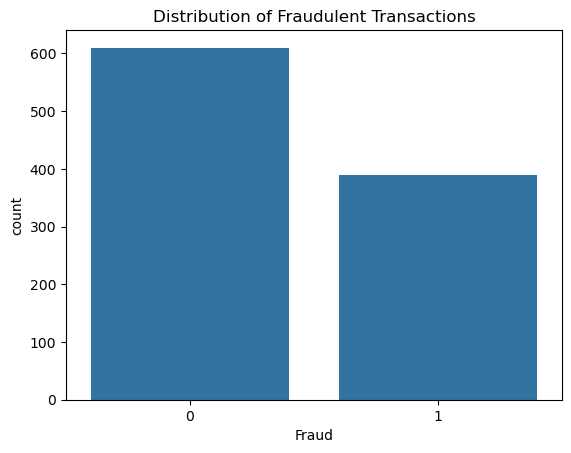

In [ ]:
#Distribution of the target variable to check for class imbalance dataset

sns.countplot(x='Fraud', data=df)
plt.title('Distribution of Fraudulent Transactions')
plt.show()

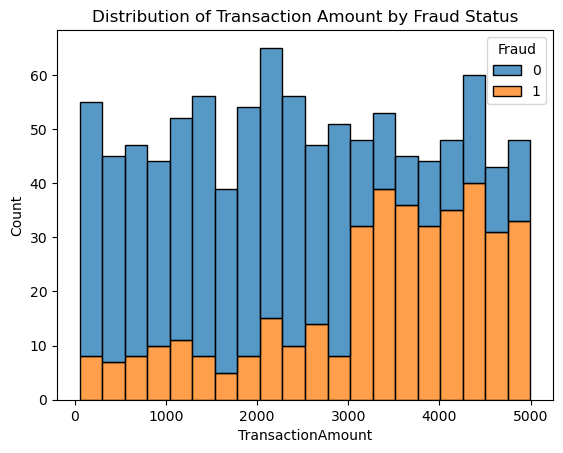

In [ ]:
#Distribution of Transaction Amount by Fraud Status
sns.histplot(data=df, x='TransactionAmount', hue='Fraud', bins=20, multiple='stack')
plt.title('Transaction Amount Distribution by Fraud Status')
plt.show()

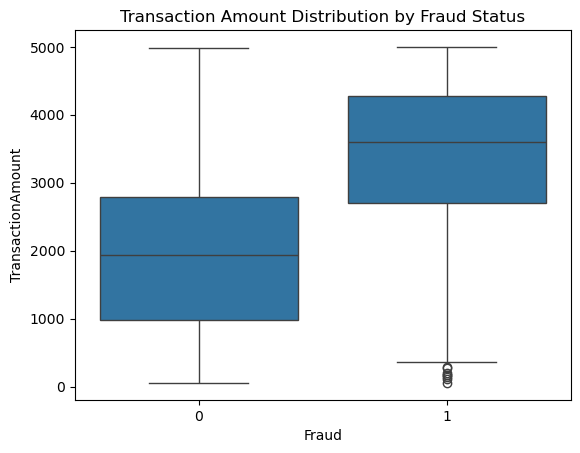

In [9]:
#Distribution of Transaction Amount by Fraud Status using boxplot
sns.boxplot(data=df, x='Fraud', y='TransactionAmount')
plt.title('Transaction Amount Distribution by Fraud Status')
plt.show()

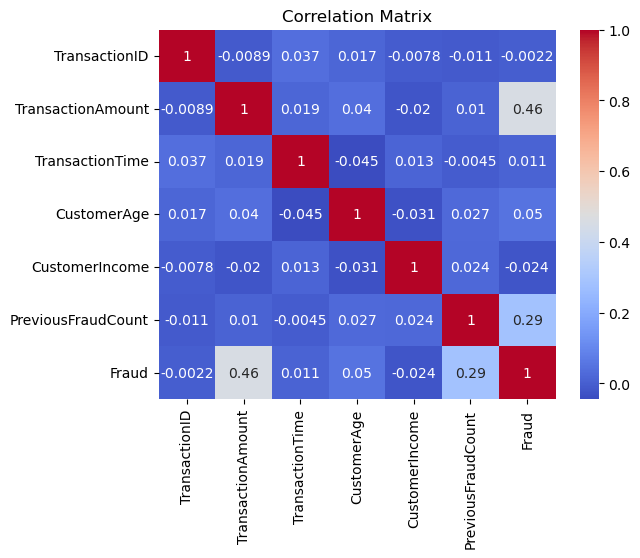

In [10]:
#Correlation Matrix

num_cols=list()

for column in df.columns:
    if df[column].dtype != 'object':
        num_cols.append(column)

correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Data Preprocessing**

In [ ]:
label_encoder={}

for column in ['MerchantCategory','CustomerGender','TransactionLocation']:
    le=LabelEncoder()
    df[column]=le.fit_transform(df[column])
    label_encoder[column]=le

#Feature and Target
X=df.drop(['TransactionID','Fraud'],axis=1)#axis=1 means drop column
y=df['Fraud']

In [13]:
X.head()

,TransactionAmount,TransactionTime,MerchantCategory,CustomerAge,CustomerGender,CustomerIncome,TransactionLocation,PreviousFraudCount
0,4910.15,5.12,4,70,0,168527,2,3
1,3928.13,14.53,7,26,1,59722,0,3
2,1501.22,20.39,0,22,0,52947,0,5
3,2477.20,13.27,5,50,0,45399,0,0
4,1512.13,9.24,0,58,0,31075,1,3


In [12]:
#Splitting the dataset into training and testing sets

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

In [14]:
#Feature Scaling

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

**Logistic Regression**

In [15]:
#Logistic Regression Model

from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression()
logreg.fit(X_train,y_train)
y_pred=logreg.predict(X_test)

logreg_accuracy=accuracy_score(y_test,y_pred)

In [16]:
#Displaying the accuracy of the Logistic Regression model

print(f"Accuracy of Logistic Regression Accuracy: {logreg_accuracy*100:.2f}%")
print("\nLogistic Regression Classfication Report:")
print(classification_report(y_test,y_pred))

Accuracy of Logistic Regression Accuracy: 78.00%

Logistic Regression Classfication Report:
              precision    recall  f1-score   support

           0       0.77      0.89      0.83       175
           1       0.80      0.62      0.70       125

    accuracy                           0.78       300
   macro avg       0.79      0.76      0.76       300
weighted avg       0.78      0.78      0.77       300



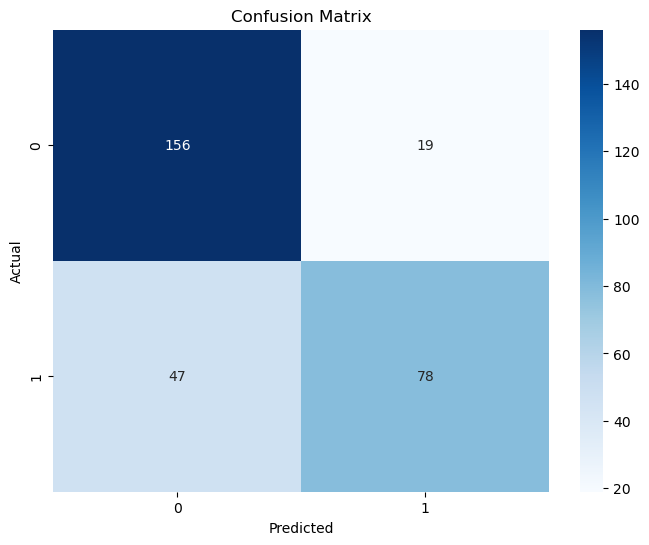

In [18]:
#Confusion Matrix

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

